In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("web_traffic.csv") 
df

,user_id,session_id,page,time_on_page,source,bounce,conversion
0,1,101,Homepage,30,Organic,1,0
1,1,102,Product Page,120,Organic,0,1
2,2,103,Homepage,15,Direct,1,0
3,3,104,Homepage,45,Social,0,0
4,3,105,Product Page,60,Social,0,0
5,3,106,Cart,30,Social,0,1
6,4,107,Homepage,10,Organic,1,0
7,5,108,Homepage,50,Referral,0,0
8,5,109,Product Page,80,Referral,0,0
9,5,110,Cart,20,Referral,1,0


In [5]:
# Check null values
print(df.isnull().sum())

user_id         0
session_id      0
page            0
time_on_page    0
source          0
bounce          0
conversion      0
dtype: int64


In [6]:
# Remove missing values
# Data Cleaning
df.dropna(inplace=True)



In [7]:
# Convert data types if needed
df['time_on_page'] = df['time_on_page'].astype(float)

In [9]:
# Show first 5 rows
print("First 5 rows:")
print(df.head())

First 5 rows:
   user_id  session_id          page  time_on_page   source  bounce  \
0        1         101      Homepage          30.0  Organic       1   
1        1         102  Product Page         120.0  Organic       0   
2        2         103      Homepage          15.0   Direct       1   
3        3         104      Homepage          45.0   Social       0   
4        3         105  Product Page          60.0   Social       0   

   conversion  
0           0  
1           1  
2           0  
3           0  
4           0  


In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       18 non-null     int64  
 1   session_id    18 non-null     int64  
 2   page          18 non-null     object 
 3   time_on_page  18 non-null     float64
 4   source        18 non-null     object 
 5   bounce        18 non-null     int64  
 6   conversion    18 non-null     int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 1.1+ KB
None


In [11]:
bounce_rate = df['bounce'].mean() * 100
print("\nBounce Rate:", bounce_rate)


Bounce Rate: 38.88888888888889


In [12]:
#  Top Pages
top_pages = df['page'].value_counts()
print("\nTop Pages:")
print(top_pages)



Top Pages:
page
Homepage        10
Product Page     6
Cart             2
Name: count, dtype: int64


In [13]:
# Step 8: Traffic Sources
traffic_sources = df['source'].value_counts()
print("\nTraffic Sources:")
print(traffic_sources)


Traffic Sources:
source
Organic     5
Social      5
Referral    5
Direct      3
Name: count, dtype: int64


In [14]:

# Step 9: Sessions per User
sessions_per_user = df.groupby('user_id')['session_id'].nunique()
print("\nSessions per User:")
print(sessions_per_user)



Sessions per User:
user_id
1     2
2     1
3     3
4     1
5     3
6     1
7     2
8     2
9     1
10    2
Name: session_id, dtype: int64


In [15]:
# Step 10: Funnel Analysis
print("\nFunnel Analysis (Page Visits):")
funnel = df['page'].value_counts()
print(funnel)


Funnel Analysis (Page Visits):
page
Homepage        10
Product Page     6
Cart             2
Name: count, dtype: int64


In [16]:
# Step 11: Drop-off Analysis
drop_off = df[df['bounce'] == 1]
print("\nDrop-off Pages:")
print(drop_off['page'].value_counts())


Drop-off Pages:
page
Homepage        5
Cart            1
Product Page    1
Name: count, dtype: int64


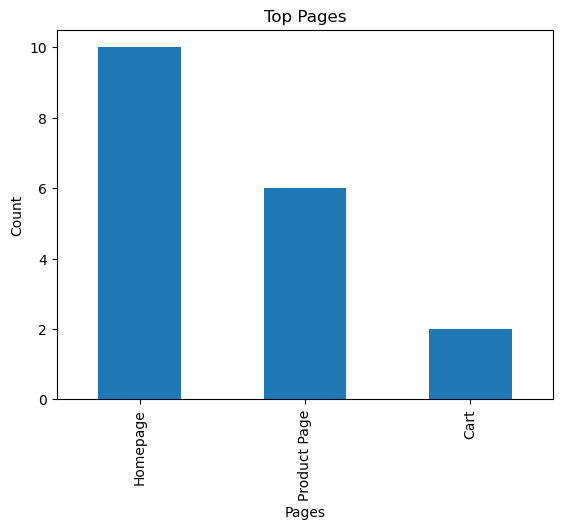

In [19]:
# Step 12: Visualization

# Top Pages Bar Chart
top_pages.plot(kind='bar')
plt.title("Top Pages")
plt.xlabel("Pages")
plt.ylabel("Count")
plt.show()


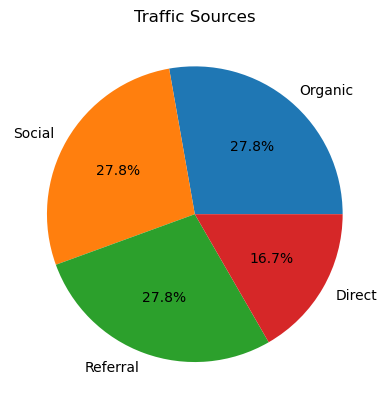

In [20]:
# Traffic Sources Pie Chart
traffic_sources.plot(kind='pie', autopct='%1.1f%%')
plt.title("Traffic Sources")
plt.ylabel("")  # remove default label
plt.show()

In [21]:
# Conversion Rate
conversion_rate = df['conversion'].mean() * 100
print("Conversion Rate:", conversion_rate)

# Average Time on Page
avg_time = df['time_on_page'].mean()
print("Average Time on Page:", avg_time)

Conversion Rate: 22.22222222222222
Average Time on Page: 49.72222222222222
